# Process Annual Water Quality Variables

This notebook demonstrates how to generate the annual water quality variables for a single task.

## Getting started

### Load required python packages

In [1]:
%load_ext water_quality.magics

In [2]:
import gc
import json
import os
import sys
import warnings

import click
import numpy as np
import toolz
import xarray as xr
from datacube import Datacube
from deafrica_tools.dask import create_local_dask_cluster
from odc import dscache
from odc.geo.xr import write_cog
from odc.stats.model import DateTimeRange

from water_quality.io import (
    check_directory_exists,
    get_filesystem,
    get_parent_dir,
    get_wq_cog_url,
    get_wq_csv_url,
    get_wq_dataset_path,
    get_wq_stac_url,
    is_s3_path,
    join_url,
)
from water_quality.logs import setup_logging
from water_quality.mapping.algorithms import WQ_vars
from water_quality.mapping.fai import geomedian_FAI
from water_quality.mapping.hue import geomedian_hue
from water_quality.mapping.instruments import (
    INSTRUMENTS_PRODUCTS,
    check_instrument_dates,
)
from water_quality.mapping.load_data import load_annual_data
from water_quality.mapping.ndvi import geomedian_NDVI
from water_quality.mapping.optical_water_type import run_OWT
from water_quality.mapping.pixel_correction import apply_R_correction
from water_quality.mapping.water_detection import (
    clear_water_mask,
    five_year_water_mask,
)
from water_quality.metadata.prepare_metadata import prepare_dataset
from water_quality.tasks import (
    create_task_id,
    filter_tasks_by_task_id,
    filter_tasks_by_tile_id,
    split_tasks,
)


### Define analysis parameters

The expected inputs:

(required_inputs):

- **cache-file-path** : Path to the file database containing the tasks and datasets to be processed, generated in the `generate-tasks` step. 
- **output-directory**: Path to the directory for output COG files, CSVs, and STAC metadata. 
- **max-parallel-steps**: Total number of parallel workers/pods available to run this workflow. If running the workflow outside of Argo Workflow e.g. in a Jupyter Notebook, set this to 1. If `max-parallel-steps` is greater than 1, tasks are split equally across all available workers.
- **worker-idx**: The sequential index (0-indexed) of the current worker (determines which task subset to process). If max parallel steps is set to 1, set this to 0.
 
Setting **max-parallel-steps** to 1 and **worker-idx** to 0 will result in this workflow being processed in serial.

- **overwrite**: If overwrite is True, tasks which have already been run and their results written to the output directory will be rerun and their output COG files and STAC metadata files be overwritten. 

In [3]:
cache_file_path = "wq_annual_annual_2000--P25Y.db"
output_directory = "test"
max_parallel_steps = 1
worker_idx = 0
overwrite = True

(optional inputs)

- **tasks**: A list of comma separated task IDs in the format "period/x{x:02d}/y{y:02d}" e.g. `2015--P1Y/x200/y034,2015--P1Y/x178/y095,2015--P1Y/x199/y100`. This is mutually exclusive to the `tiles` option. 
- **tiles**: A list of comma seperated tile IDs in the format "x{x:02d}/y{y:02d}" e.g `x200/y034,x178/y095,x199/y100`.

This notebook is designed to run a single task only, which we will specify below. 

In [4]:
tasks = "2023--P1Y/x217/y077"
tiles = ""

## Processing

Setup the logger for this notebook. 
By default logging is set to INFO level. 

In [5]:
log = setup_logging()

Open the file database. 

In [6]:
if is_s3_path(cache_file_path):
    local_cache_file_path = "/tmp/cachedb.db"
    fs = get_filesystem(cache_file_path, anon=False)
    fs.get(cache_file_path, local_cache_file_path)
    log.info(
        f"Downloaded cache file from {cache_file_path} to {local_cache_file_path}"
    )
    cache = dscache.open_ro(local_cache_file_path)
else:
    cache = dscache.open_ro(cache_file_path)

Load analysis parameters and product metadata from the file database metadata. 
This includes:

- **WFTH** : The WOfS Annual frequency threshold above which a pixel is classified as general water. This used during the water detection step to generate the annual water mask. 

- **product name** and **product version**: This is the ODC product name and version (metadata) for the water quality variables to be processed. The convention for the product name is `wq_<frequency>` e.g. for annual water quality variables the product name  is `wq_annual`. 

- **instruments_to_use** : This defines instruments to be used in generating the water quality variables. The table below matches the instrument names to the ODC products loaded for the instrument. Instruments to be used have their "use" parameter set to True.

| Instrument Key | Products                               |
| -------------- | -------------------------------------- |
| `tm_agm`       | `gm_ls5_ls7_annual`                    |
| `oli_agm`      | `gm_ls8_annual`, `gm_ls8_ls9_annual`   |
| `msi_agm`      | `gm_s2_annual`                         |
| `wofs_ann`     | `wofs_ls_summary_annual`               |
| `tirs`         | `ls5_st`, `ls7_st`, `ls8_st`, `ls9_st` |
| `tm`           | `ls5_sr`, `ls7_sr`                     |
| `oli`          | `ls8_sr`, `ls9_sr`                     |
| `msi`          | `s2_l2a`                               |

    When running the annual water quality variables the expected instruments are : `oli_agm`, `msi_agm`, `tm_agm`, `tirs` and `wofs_ann` with `wofs_ann` being mandatory.
    For frequencies shorter than a year the expected instruments are: `oli`, `msi`, `tm`, `tirs` and `wofs_ann` with `wofs_ann` being mandatory.

- The name and actual spatial grid used for processing. 

In [7]:
# This should have been validated during task generation.
config = cache.get_info_dict("wq_config")
WFTH = config["WFTH"]
product_name = config["product_name"]
product_version = config["product_version"]
# Instruments to use should also have been validated
# during task generation.
cfg_instruments_to_use = config["instruments_to_use"]
# Grid properties
grid_name = config["grid_name"]
grid_spec = cache.grids[grid_name]

Filter the tasks present in the file database using the tasks or tiles specified in the input parameters. 

In [8]:
input_products = {
    v: k for k, vals in INSTRUMENTS_PRODUCTS.items() for v in vals
}

# Load all tasks and split for this worker
all_task_ids = sorted([i[0] for i in cache.tiles(grid_name)])

if tasks and tiles:
    raise ValueError("Use either tasks or tiles, not both.")
else:
    if tasks or tiles:
        if tasks:
            filtered_tasks = filter_tasks_by_task_id(
                all_task_ids=all_task_ids, task_ids=tasks
            )
            filter_str = tasks
        else:
            filtered_tasks = filter_tasks_by_tile_id(
                all_task_ids=all_task_ids, tile_ids=tiles
            )
            filter_str = tiles

        if len(filtered_tasks) == 0:
            error_msg = f"No matching tasks found in the file database for the provided filter: {filter_str}."
            log.error(error_msg)
            sys.exit(1)
        else:
            log.info(
                f"Found {len(filtered_tasks)} matching task(s) "
                f"in the file database for the provided filter: {filter_str}."
            )
            tasks_to_run = split_tasks(
                filtered_tasks, max_parallel_steps, worker_idx
            )
    else:
        tasks_to_run = split_tasks(
            all_task_ids, max_parallel_steps, worker_idx
        )

if not tasks_to_run:
    log.warning(f"Worker {worker_idx} has no tasks to process. Exiting.")
    sys.exit(0)

log.info(f"Worker {worker_idx} processing {len(tasks_to_run)} task(s)")

dc = Datacube(app="ProcessAnnualWQVariables")

2026-01-09 11:44:56,084 __main__ [INFO]: Found 1 matching task(s) in the file database for the provided filter: 2023--P1Y/x217/y077.
2026-01-09 11:44:56,085 __main__ [INFO]: Worker 0 processing 1 task(s)


In [9]:
task_id = tasks_to_run[0]

Get the time range and tile components of the task.

In [10]:
temporal_id, tile_idx, tile_idy = task_id
tile_id = (tile_idx, tile_idy)
task_id_str = create_task_id(temporal_id, tile_id)
tile_geobox = grid_spec.tile_geobox(tile_index=tile_id)
log.info(f"Processing task: {task_id_str}")

2026-01-09 11:44:56,662 __main__ [INFO]: Processing task: 2023--P1Y/x217/y077


In [11]:
temporal_id

'2023--P1Y'

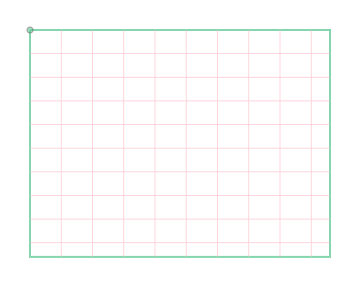

In [12]:
tile_geobox

In this notebook, we will edit the tile geobox to cover a smaller test area. 
In the [Generate Tasks notebook](./GenerateTasks.ipynb) the `place-name` option was used to define the area of interest. 
We will use the same test area to edit the tile geobox. 

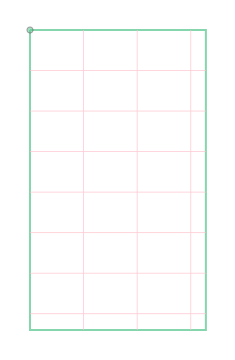

In [13]:
from importlib.resources import files
from odc.geo.geobox import GeoBox
from odc.geo.geom import Geometry
import geopandas as gpd

place_name = "Lake_Baringo"
places_fp = files("water_quality.data").joinpath("places.parquet")
places_gdf = gpd.read_parquet(places_fp)
place = places_gdf[places_gdf["name"].isin([place_name])]
aoi_geom = Geometry(geom=place.iloc[0].geometry, crs=place.crs)

tile_geobox = GeoBox.from_geopolygon(aoi_geom, crs=tile_geobox.crs, resolution=tile_geobox.resolution)
tile_geobox

Validate the instruments to use from the file database metadata against the time range for the task. 

In [14]:
temporal_range = DateTimeRange(temporal_id)
start_date = temporal_range.start.strftime("%Y-%m-%d")
end_date = temporal_range.end.strftime("%Y-%m-%d")
instruments_to_use = check_instrument_dates(  # noqa F841
    cfg_instruments_to_use,
    start_date,
    end_date,
    raise_errors=False,
)
instruments_to_use

2026-01-09 11:44:56,868 water_quality.mapping.instruments [ERROR]: Instrument tm_agm has data for the date range 1990-01-01 to 2012-12-31 which is outside the requested date range of 2023-01-01 to 2023-12-31. 
Instrument use set to False


{'oli_agm': {'use': True},
 'oli': {'use': False},
 'msi_agm': {'use': True},
 'msi': {'use': False},
 'tm_agm': {'use': False},
 'tm': {'use': False},
 'tirs': {'use': True},
 'wofs_ann': {'use': True}}

Based on whether **overwrite** was set to True or False and if the STAC metadata file for the task exists, determine if the task will be processed.

In [15]:
expected_stac_path = get_wq_stac_url(
    get_wq_dataset_path(
        output_directory=output_directory,
        tile_id=tile_id,
        temporal_id=temporal_id,
        product_name=product_name,
        product_version=product_version,
    )
)
exists = check_directory_exists(expected_stac_path)
if exists and not overwrite:
    log.info(
        f"STAC file already exists for task {task_id_str} at "
        f"{expected_stac_path} and overwrite is False. "
        "Skipping processing for this task."
    )
    # continue
    sys.exit("Stopping notebook execution here")

Stream the datasets to be processed for the task from the file database and group the datasets by the instrument.

In [16]:
dss = list(cache.stream_grid_tile(task_id, grid_name))
dss = toolz.groupby(
    lambda ds: input_products[ds.product.name], dss
)

In [17]:
print(dss.keys())

dict_keys(['tirs', 'wofs_ann', 'oli_agm', 'msi_agm'])


In [18]:
from deafrica_tools.dask import create_local_dask_cluster
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/victoria.neema@digitalearthafrica.org/proxy/8787/status,
Dashboard: /user/victoria.neema@digitalearthafrica.org/proxy/8787/status,Workers: 1
Total threads: 4,Total memory: 26.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44929,Workers: 0
Dashboard: /user/victoria.neema@digitalearthafrica.org/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:34565,Total threads: 4
Dashboard: /user/victoria.neema@digitalearthafrica.org/proxy/42829/status,Memory: 26.21 GiB
Nanny: tcp://127.0.0.1:38077,


Load the datasets into a dictionary, mapping instrument names to the xarray objects containing the data loaded for the task. 

In [19]:
# Load annual data for all instruments
annual_data = load_annual_data(
    dss=dss,
    tile_geobox=tile_geobox,
    compute=False,
    dc=dc,
)
annual_data

2026-01-09 11:44:59,721 water_quality.mapping.load_data [INFO]: Loading data for the instrument 'wofs_ann' ...
2026-01-09 11:44:59,919 water_quality.mapping.load_data [INFO]: Loading data for the instrument 'oli_agm' ...
2026-01-09 11:44:59,949 water_quality.mapping.load_data [INFO]: Loading data for the instrument 'msi_agm' ...
2026-01-09 11:44:59,987 water_quality.mapping.load_data [INFO]: Loading data for the instrument 'tirs' ...


{'wofs_ann': <xarray.Dataset> Size: 364MB
 Dimensions:              (time: 5, y: 3701, x: 1641)
 Coordinates:
   * time                 (time) datetime64[ns] 40B 2019-07-02T11:59:59.999999...
   * y                    (y) float64 30kB 9.44e+04 9.44e+04 ... 5.74e+04
   * x                    (x) float64 13kB 3.474e+06 3.474e+06 ... 3.49e+06
     spatial_ref          int32 4B 6933
 Data variables:
     wofs_ann_freq        (time, y, x) float32 121MB dask.array<chunksize=(5, 3701, 1641), meta=np.ndarray>
     wofs_ann_clearcount  (time, y, x) float32 121MB dask.array<chunksize=(5, 3701, 1641), meta=np.ndarray>
     wofs_ann_wetcount    (time, y, x) float32 121MB dask.array<chunksize=(5, 3701, 1641), meta=np.ndarray>,
 'oli_agm': <xarray.Dataset> Size: 170MB
 Dimensions:        (time: 1, y: 3701, x: 1641)
 Coordinates:
   * time           (time) datetime64[ns] 8B 2023-07-02T11:59:59.999999
   * y              (y) float64 30kB 9.44e+04 9.44e+04 ... 5.742e+04 5.74e+04
   * x              (x)

Instatiate a dictionary to store the results from each processing step. 

In [20]:
wq_ds = {}

Generate the 5 year water mask using the `wofs_ann` instrument data. 

In [21]:
wq_ds["water_mask"] = five_year_water_mask(
    annual_data=annual_data,
    compute=True,
)
gc.collect()
wq_ds["water_mask"]

2026-01-09 11:45:00,432 water_quality.mapping.water_detection [INFO]: Generating 5 year water mask ...
2026-01-09 11:45:00,450 water_quality.mapping.water_detection [INFO]: 	Computing water mask ...
/opt/venv/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
2026-01-09 11:45:02,031 water_quality.mapping.water_detection [INFO]: Processing complete for water mask.


<xarray.DataArray 'water_mask' (time: 1, y: 3701, x: 1641)> Size: 24MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 3701, 1641), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 8B 2023-07-02T11:59:59.999999
  * y            (y) float64 30kB 9.44e+04 9.44e+04 ... 5.742e+04 5.74e+04
  * x            (x) float64 13kB 3.474e+06 3.474e+06 ... 3.49e+06 3.49e+06
    spatial_ref  int32 4B 6933
Attributes:
    nodata:   nan
    scales:   1
    offsets:  0

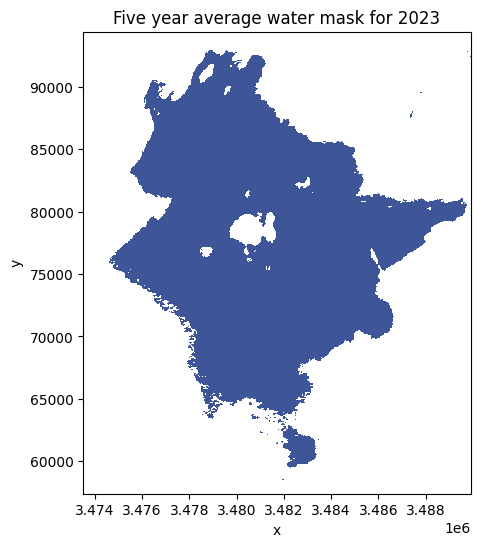

In [22]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,6))

cmap = mcolors.ListedColormap(["none", "#3E5697"])

wq_ds["water_mask"].plot(
    ax=ax,
    cmap=cmap,
    vmin=0,
    vmax=1,
    add_colorbar=False
)

year = wq_ds["water_mask"].time.dt.year.values.item()
plt.title(f"Five year average water mask for {year}");
plt.show()

Generate the water temperature water quality variables. 

In [23]:
%%time
from water_quality.mapping.temperature import water_temperature
wq_ds["water_temp"] = water_temperature(annual_data=annual_data, water_mask=wq_ds["water_mask"], compute=True)
wq_ds["water_temp"]

2026-01-09 11:45:04,793 water_quality.mapping.temperature [INFO]: Processing water temperature annual composite ...
2026-01-09 11:45:14,899 water_quality.mapping.temperature [INFO]: 	Computing water temperature dataset ...
/opt/venv/lib/python3.12/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(
2026-01-09 11:46:20,455 water_quality.mapping.temperature [INFO]: Processing complete for water temperature dataset.


CPU times: user 11.4 s, sys: 1.1 s, total: 12.5 s
Wall time: 1min 15s


<xarray.Dataset> Size: 146MB
Dimensions:          (time: 1, y: 3701, x: 1641)
Coordinates:
  * time             (time) datetime64[ns] 8B 2023-07-02T11:59:59.999999
  * y                (y) float64 30kB 9.44e+04 9.44e+04 ... 5.742e+04 5.74e+04
  * x                (x) float64 13kB 3.474e+06 3.474e+06 ... 3.49e+06 3.49e+06
    quantile         float64 8B 0.1
    spatial_ref      int32 4B 6933
Data variables:
    tirs_st_ann_med  (time, y, x) float64 49MB nan nan nan nan ... nan nan nan
    tirs_st_ann_min  (time, y, x) float64 49MB nan nan nan nan ... nan nan nan
    tirs_st_ann_max  (time, y, x) float64 49MB nan nan nan nan ... nan nan nan

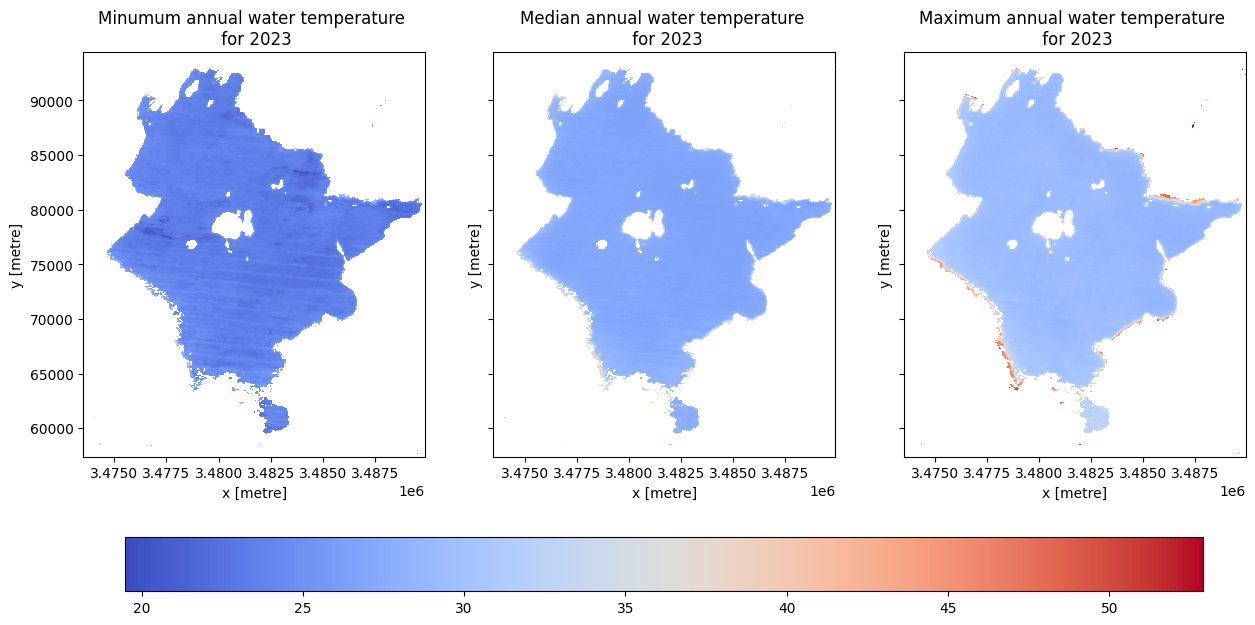

In [24]:
water_temp_bands = list(wq_ds["water_temp"].data_vars)

vmin = min([float(wq_ds["water_temp"][band].min()) for band in water_temp_bands])
vmax = max([float(wq_ds["water_temp"][band].max()) for band in water_temp_bands])

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = "coolwarm"

fig, ax = plt.subplots(1, 3, sharey=True, figsize=(15, 7))

wq_ds["water_temp"]["tirs_st_ann_min"].plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
ax[0].set_title(f"Minumum annual water temperature \n for {year}")

wq_ds["water_temp"]["tirs_st_ann_med"].plot(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
ax[1].set_title(f"Median annual water temperature \n for {year}")

im = wq_ds["water_temp"]["tirs_st_ann_max"].plot(ax=ax[2], cmap=cmap, norm=norm, add_colorbar=False)
ax[2].set_title(f"Maximum annual water temperature \n for {year}")

fig.colorbar(im, ax=ax, orientation='horizontal', fraction=.1)

plt.show()

Calculate the Floating Algae Index (FAI) for the available instruments.

In [25]:
%%time
wq_ds["fai"] = geomedian_FAI(
    annual_data=annual_data,
    water_mask=wq_ds["water_mask"],
    compute=True,
)
gc.collect()
wq_ds["fai"] 

2026-01-09 11:46:28,269 water_quality.mapping.fai [INFO]: Calculating Geomedian FAI for available instruments ...
2026-01-09 11:46:28,270 water_quality.mapping.fai [INFO]: 	Calculating FAI for instrument: msi_agm ...
2026-01-09 11:46:28,278 water_quality.mapping.fai [INFO]: 	Calculating FAI for instrument: oli_agm ...
2026-01-09 11:46:28,344 water_quality.mapping.fai [INFO]: 	Computing FAI dataset ...
2026-01-09 11:46:30,323 water_quality.mapping.fai [INFO]: Geomedian FAI calculation complete.


CPU times: user 413 ms, sys: 82.2 ms, total: 495 ms
Wall time: 2.33 s


<xarray.Dataset> Size: 73MB
Dimensions:      (time: 1, y: 3701, x: 1641)
Coordinates:
  * time         (time) datetime64[ns] 8B 2023-07-02T11:59:59.999999
  * y            (y) float64 30kB 9.44e+04 9.44e+04 ... 5.742e+04 5.74e+04
  * x            (x) float64 13kB 3.474e+06 3.474e+06 ... 3.49e+06 3.49e+06
    spatial_ref  int32 4B 6933
Data variables:
    msi_agm_fai  (time, y, x) float32 24MB nan nan nan nan ... nan nan nan nan
    oli_agm_fai  (time, y, x) float32 24MB nan nan nan nan ... nan nan nan nan
    agm_fai      (time, y, x) float32 24MB nan nan nan nan ... nan nan nan nan

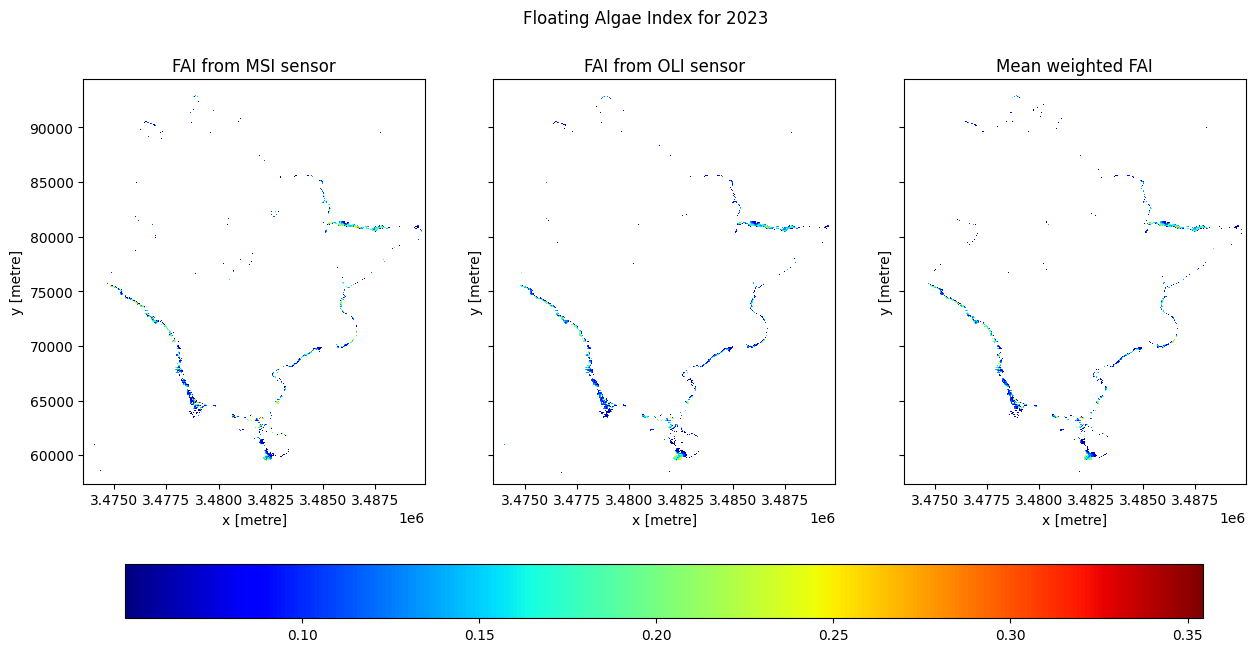

In [26]:
fai_bands = list(wq_ds["fai"].data_vars)

vmin = min([float(wq_ds["fai"][band].min()) for band in fai_bands])
vmax = max([float(wq_ds["fai"][band].max()) for band in fai_bands])

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.jet

fig, ax = plt.subplots(1, 3, sharey=True, figsize=(15, 7))
fig.suptitle(f"Floating Algae Index for {year}")

wq_ds["fai"]["msi_agm_fai"].plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
ax[0].set_title(f"FAI from MSI sensor")

wq_ds["fai"]["oli_agm_fai"].plot(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
ax[1].set_title(f"FAI from OLI sensor")

im = wq_ds["fai"]["agm_fai"].plot(ax=ax[2], cmap=cmap, norm=norm, add_colorbar=False)
ax[2].set_title(f"Mean weighted FAI")

fig.colorbar(im, ax=ax, orientation='horizontal', fraction=.1)

plt.show()

In [27]:
%%time
# Calculate the clear water mask.
wq_ds["clear_water"] = clear_water_mask(
    annual_data=annual_data,
    water_frequency_threshold=WFTH,
    water_mask=wq_ds["water_mask"],
    agm_fai=wq_ds["fai"]["agm_fai"],
    compute=True,
)
gc.collect()
wq_ds["clear_water"]

2026-01-09 11:46:37,483 water_quality.mapping.water_detection [INFO]: Calculating clear water mask ...
2026-01-09 11:46:37,506 water_quality.mapping.water_detection [INFO]: 	Computing clear water mask ...
2026-01-09 11:46:38,752 water_quality.mapping.water_detection [INFO]: Processing complete for clear water mask.


CPU times: user 350 ms, sys: 21.6 ms, total: 372 ms
Wall time: 1.55 s


<xarray.DataArray 'clear_water' (time: 1, y: 3701, x: 1641)> Size: 24MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(1, 3701, 1641), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 8B 2023-07-02T11:59:59.999999
  * y            (y) float64 30kB 9.44e+04 9.44e+04 ... 5.742e+04 5.74e+04
  * x            (x) float64 13kB 3.474e+06 3.474e+06 ... 3.49e+06 3.49e+06
    spatial_ref  int32 4B 6933
Attributes:
    nodata:   nan
    scales:   1
    offsets:  0

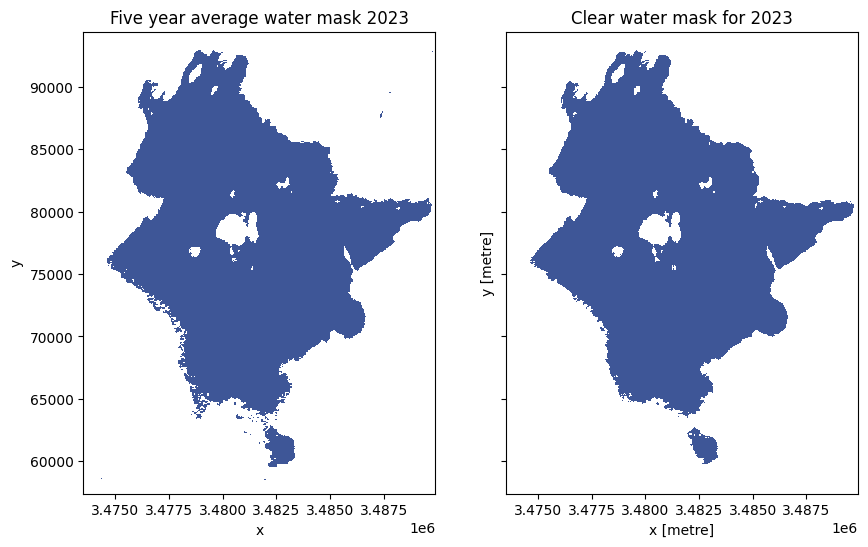

In [28]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(10,6))

cmap = mcolors.ListedColormap(["none", "#3E5697"])

wq_ds["water_mask"].plot(
    ax=ax[0],
    cmap=cmap,
    vmin=0,
    vmax=1,
    add_colorbar=False
)
ax[0].set_title(f"Five year average water mask {year}")


wq_ds["clear_water"].plot(
    ax=ax[1],
    cmap=cmap,
    vmin=0,
    vmax=1,
    add_colorbar=False
)
ax[1].set_title(f"Clear water mask for {year}")

plt.show()

Calculate the Normalized Difference Vegetation Index (NDVI) for the available instruments.

In [29]:
%%time

wq_ds["ndvi"] = geomedian_NDVI(
    annual_data=annual_data,
    water_mask=wq_ds["water_mask"],
    compute=True,
)
gc.collect()
wq_ds["ndvi"]

2026-01-09 11:46:43,528 water_quality.mapping.ndvi [INFO]: Calculating Geomedian NDVI for available instruments ...
2026-01-09 11:46:43,529 water_quality.mapping.ndvi [INFO]: 	Calculating NDVI for instrument: msi_agm ...
2026-01-09 11:46:43,535 water_quality.mapping.ndvi [INFO]: 	Calculating NDVI for instrument: oli_agm ...
2026-01-09 11:46:43,597 water_quality.mapping.ndvi [INFO]: 	Computing NDVI dataset ...
2026-01-09 11:46:44,662 water_quality.mapping.ndvi [INFO]: Geomedian NDVI calculation complete.


CPU times: user 371 ms, sys: 61.9 ms, total: 433 ms
Wall time: 1.39 s


<xarray.Dataset> Size: 73MB
Dimensions:       (time: 1, y: 3701, x: 1641)
Coordinates:
  * time          (time) datetime64[ns] 8B 2023-07-02T11:59:59.999999
  * y             (y) float64 30kB 9.44e+04 9.44e+04 ... 5.742e+04 5.74e+04
  * x             (x) float64 13kB 3.474e+06 3.474e+06 ... 3.49e+06 3.49e+06
    spatial_ref   int32 4B 6933
Data variables:
    msi_agm_ndvi  (time, y, x) float32 24MB nan nan nan nan ... nan nan nan nan
    oli_agm_ndvi  (time, y, x) float32 24MB nan nan nan nan ... nan nan nan nan
    agm_ndvi      (time, y, x) float32 24MB nan nan nan nan ... nan nan nan nan

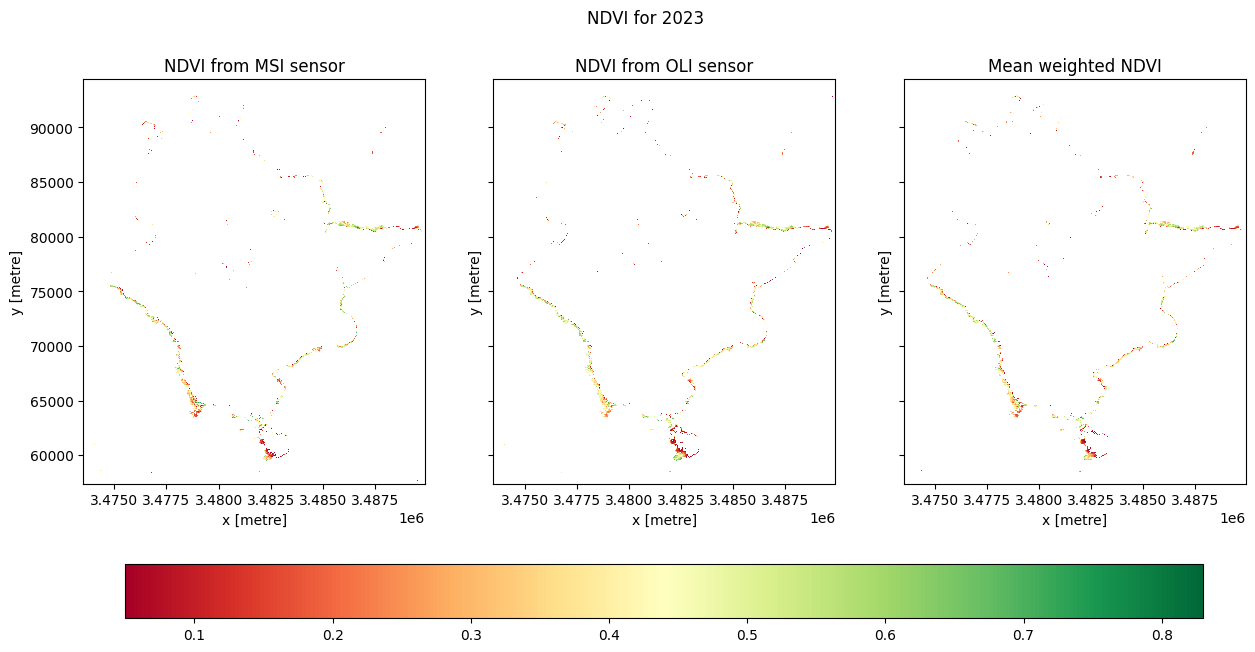

In [30]:
ndvi_bands = list(wq_ds["ndvi"].data_vars)

vmin = min([float(wq_ds["ndvi"][band].min()) for band in ndvi_bands])
vmax = max([float(wq_ds["ndvi"][band].max()) for band in ndvi_bands])

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = "RdYlGn"

fig, ax = plt.subplots(1, 3, sharey=True, figsize=(15, 7))
fig.suptitle(f"NDVI for {year}")

wq_ds["ndvi"]["msi_agm_ndvi"].plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
ax[0].set_title(f"NDVI from MSI sensor")

wq_ds["ndvi"]["oli_agm_ndvi"].plot(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
ax[1].set_title(f"NDVI from OLI sensor")

im = wq_ds["ndvi"]["agm_ndvi"].plot(ax=ax[2], cmap=cmap, norm=norm, add_colorbar=False)
ax[2].set_title(f"Mean weighted NDVI")

fig.colorbar(im, ax=ax, orientation='horizontal', fraction=.1)

plt.show()

Apply Rayleigh correction to the available instruments.

In [31]:
annual_data = apply_R_correction(
    instrument_data=annual_data,
    water_mask=wq_ds["water_mask"],
    compute=False,
    drop=True,
)
gc.collect()

2026-01-09 11:46:51,783 water_quality.mapping.pixel_correction [WARNING]: R correction not implemented for instrument: wofs_ann
2026-01-09 11:46:51,784 water_quality.mapping.pixel_correction [INFO]: Applying R correction for instrument: oli_agm
2026-01-09 11:46:51,842 water_quality.mapping.pixel_correction [WARNING]: Variable oli01_agm expected but not found in the dataset - (non-fatal error) for instrument oli_agm
2026-01-09 11:46:51,843 water_quality.mapping.pixel_correction [INFO]: R correction complete for oli_agm.
2026-01-09 11:46:51,843 water_quality.mapping.pixel_correction [INFO]: Applying R correction for instrument: msi_agm
2026-01-09 11:46:51,900 water_quality.mapping.pixel_correction [WARNING]: Variable msi01_agm expected but not found in the dataset - (non-fatal error) for instrument msi_agm
2026-01-09 11:46:51,954 water_quality.mapping.pixel_correction [INFO]: R correction complete for msi_agm.
2026-01-09 11:46:51,954 water_quality.mapping.pixel_correction [WARNING]: R co

17521

Calculate the Hue for the available instruments.

In [32]:
%%time
wq_ds["hue"] = geomedian_hue(
    annual_data=annual_data,
    clear_water_mask=wq_ds["clear_water"],
    compute=True,
)
gc.collect()
wq_ds["hue"]

2026-01-09 11:46:52,208 water_quality.mapping.hue [INFO]: Calculating Geomedian Hue for available instruments ...
2026-01-09 11:46:52,209 water_quality.mapping.hue [INFO]: 	Calculating Hue for instrument: msi_agm ...
2026-01-09 11:46:52,296 water_quality.mapping.hue [INFO]: 	Calculating Hue for instrument: oli_agm ...
2026-01-09 11:46:52,297 water_quality.mapping.hue [ERROR]: Aborting hue calculation for instrument oli_agm due to lack of necessary data bands
2026-01-09 11:46:52,363 water_quality.mapping.hue [INFO]: 	Computing Hue dataset ...
/opt/venv/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 11.67 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
2026-01-09 11:46:54,501 water_quality.mapping.hu

CPU times: user 511 ms, sys: 100 ms, total: 612 ms
Wall time: 2.56 s


<xarray.Dataset> Size: 122MB
Dimensions:      (time: 1, y: 3701, x: 1641)
Coordinates:
  * time         (time) datetime64[ns] 8B 2023-07-02T11:59:59.999999
  * y            (y) float64 30kB 9.44e+04 9.44e+04 ... 5.742e+04 5.74e+04
  * x            (x) float64 13kB 3.474e+06 3.474e+06 ... 3.49e+06 3.49e+06
    spatial_ref  int32 4B 6933
Data variables:
    msi_agm_hue  (time, y, x) float64 49MB nan nan nan nan ... nan nan nan nan
    oli_agm_hue  (time, y, x) float32 24MB nan nan nan nan ... nan nan nan nan
    agm_hue      (time, y, x) float64 49MB nan nan nan nan ... nan nan nan nan

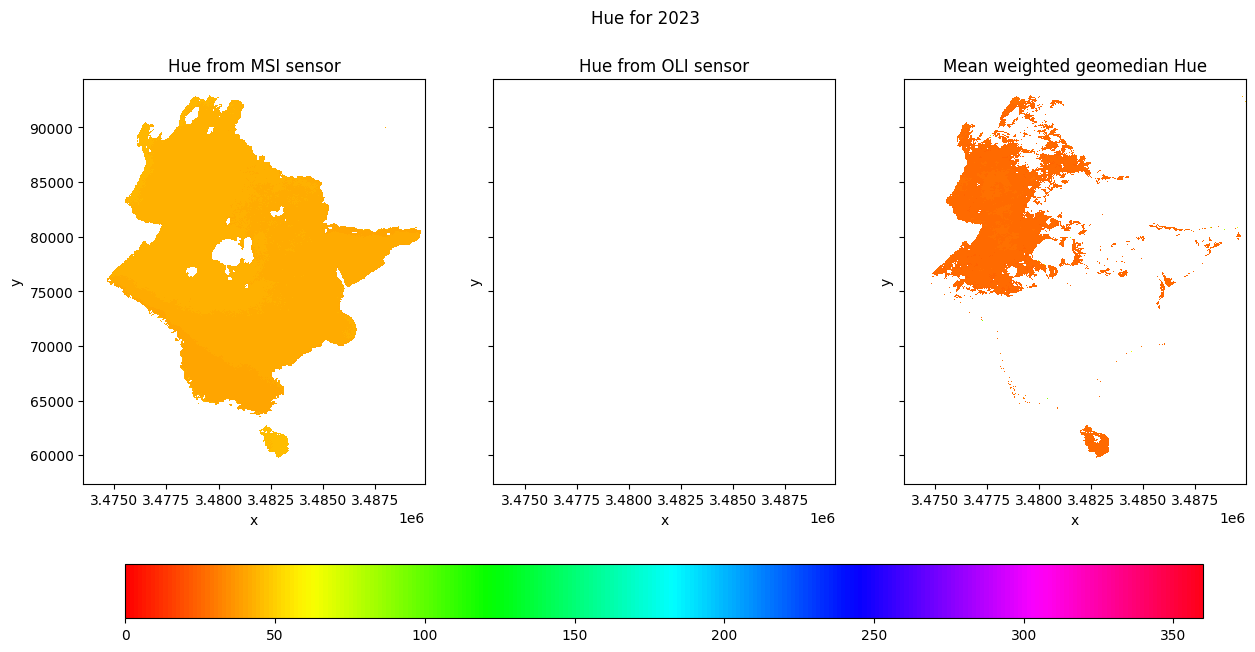

In [33]:
hue_bands = list(wq_ds["hue"].data_vars)

# vmin = min([float(wq_ds["hue"][band].min()) for band in hue_bands])
vmin = 0
# vmax = max([float(wq_ds["hue"][band].max()) for band in hue_bands])
vmax = 360

norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = "hsv"

fig, ax = plt.subplots(1, 3, sharey=True, figsize=(15, 7))
fig.suptitle(f"Hue for {year}")

wq_ds["hue"]["msi_agm_hue"].plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
ax[0].set_title(f"Hue from MSI sensor")

wq_ds["hue"]["oli_agm_hue"].plot(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
ax[1].set_title(f"Hue from OLI sensor")

im = wq_ds["hue"]["agm_hue"].plot(ax=ax[2], cmap=cmap, norm=norm, add_colorbar=False)
ax[2].set_title(f"Mean weighted geomedian Hue")

fig.colorbar(im, ax=ax, orientation='horizontal', fraction=.1)

plt.show()

Run Optical Water Type classification.

In [34]:
%%time
wq_ds["owt"] = run_OWT(
    instrument_data=annual_data,
    clear_water_mask=wq_ds["clear_water"],
    compute=True,
)
gc.collect()
wq_ds["owt"]

2026-01-09 11:47:01,485 water_quality.mapping.optical_water_type [INFO]: Running OWT classification for instrument: oli_agm ...
2026-01-09 11:47:01,561 water_quality.mapping.optical_water_type [INFO]: Calculating Optical Water Type (OWT) for instrument: oli
2026-01-09 11:47:01,821 water_quality.mapping.optical_water_type [INFO]: Running OWT classification for instrument: msi_agm ...
2026-01-09 11:47:01,923 water_quality.mapping.optical_water_type [INFO]: Calculating Optical Water Type (OWT) for instrument: msi
2026-01-09 11:47:02,230 water_quality.mapping.optical_water_type [INFO]: 	Computing OWT  ...
/opt/venv/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 11.82 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  wa

CPU times: user 1.65 s, sys: 132 ms, total: 1.78 s
Wall time: 8.36 s


<xarray.Dataset> Size: 73MB
Dimensions:      (time: 1, y: 3701, x: 1641)
Coordinates:
  * time         (time) datetime64[ns] 8B 2023-07-02T11:59:59.999999
  * y            (y) float64 30kB 9.44e+04 9.44e+04 ... 5.742e+04 5.74e+04
  * x            (x) float64 13kB 3.474e+06 3.474e+06 ... 3.49e+06 3.49e+06
    spatial_ref  int32 4B 6933
Data variables:
    oli_agm_owt  (time, y, x) float32 24MB nan nan nan nan ... nan nan nan nan
    msi_agm_owt  (time, y, x) float32 24MB nan nan nan nan ... nan nan nan nan
    agm_owt      (time, y, x) float32 24MB nan nan nan nan ... nan nan nan nan

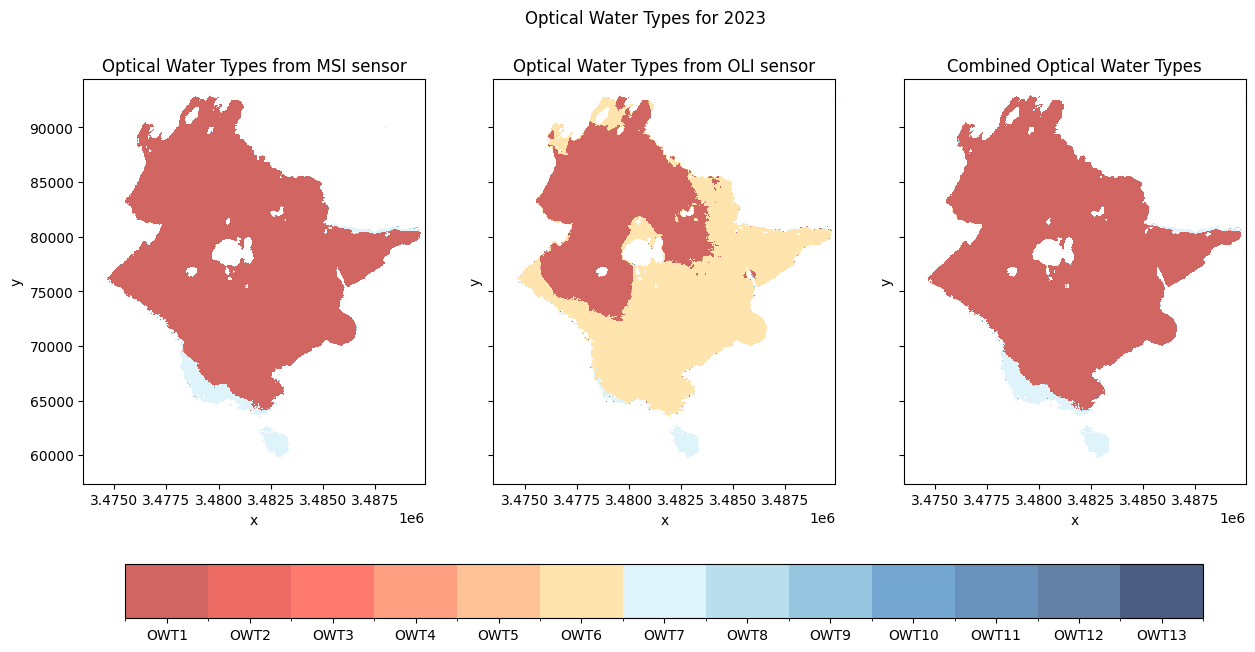

In [35]:
colors = ["#D06562", "#ED6B65", "#FE796E", "#FF9F81", "#FFC296", "#FFE5AD", 
          "#DEF3FA", "#B9DEEE", "#97C6E0", "#74A7D2", "#6992BC", "#6380A6", "#4B5D82"]
levels = list(range(1, 15, 1))
labels = [f"OWT{i}" for i in levels]

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, cmap.N)

owt_bands = list(wq_ds["owt"].data_vars)

fig, ax = plt.subplots(1, 3, sharey=True, figsize=(15, 7))
fig.suptitle(f"Optical Water Types for {year}")

wq_ds["owt"]["msi_agm_owt"].plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
ax[0].set_title(f"Optical Water Types from MSI sensor")

wq_ds["owt"]["oli_agm_owt"].plot(ax=ax[1], cmap=cmap, norm=norm, add_colorbar=False)
ax[1].set_title(f"Optical Water Types from OLI sensor")

im = wq_ds["owt"]["agm_owt"].plot(ax=ax[2], cmap=cmap, norm=norm, add_colorbar=False)
ax[2].set_title(f"Combined Optical Water Types")

cbar_ticks = [i + 0.5 for i in levels]
cbar = fig.colorbar(im, ax=ax, ticks=cbar_ticks, orientation='horizontal', fraction=.1)
cbar.set_ticklabels(labels)

plt.show()

The following table provides the dominant characteristics of OWTs in inland waters from [Spyrakos et al. (2018))](https://doi.org/10.1002/lno.10674).

| OWT   | Dominant characteristics                                                                 |
|-------|-----------------------------------------------------------------------------------------|
| OWT1  | Hypereutrophic waters with scum of cyanobacterial bloom and vegetation-like Rrs         |
| OWT2  | Common case waters with diverse reflectance shape and marginal dominance of pigments and CDOM over inorganic suspended particles |
| OWT3  | Clear waters                                                                            |
| OWT4  | Turbid waters with high organic content                                                 |
| OWT5  | Sediment-laden waters                                                                   |
| OWT6  | Balanced effects of optically active constituents at shorter wavelength                 |
| OWT7  | Highly productive waters with high cyanobacteria abundance and elevated reflectance at red/near-infrared spectral region |
| OWT8  | Productive waters with cyanobacteria presence and with Rrs peak close to 700 nm        |
| OWT9  | Optically neighboring to OWT2 waters but with higher Rrs at shorter wavelengths        |
| OWT10 | CDOM-rich waters                                                                         |
| OWT11 | Waters high in CDOM with cyanobacteria presence and high absorption efficiency by NAP  |
| OWT12 | Turbid, moderately productive waters with cyanobacteria presence                        |
| OWT13 | Very clear blue waters                                                                  |


In [36]:
%%time
# Calculate TSM, TSI and Chla Water Quality variables
wq_ds["tsm_chla_tsi"], wq_vars_df = WQ_vars(
    annual_data=annual_data,
    water_mask=wq_ds["water_mask"],
    compute=True,
    stack_wq_vars=True,
)
gc.collect()
wq_ds["tsm_chla_tsi"]

2026-01-09 11:47:16,742 water_quality.mapping.algorithms [INFO]: Running TSM water quality algorithms ...
2026-01-09 11:47:16,813 water_quality.mapping.algorithms [INFO]: Running Chla water quality algorithms ...
2026-01-09 11:47:16,861 water_quality.mapping.algorithms [INFO]: Applying normalisation parameters to water quality variables
2026-01-09 11:47:16,861 water_quality.mapping.algorithms [INFO]: Stacking water quality variables ...
2026-01-09 11:47:16,924 water_quality.mapping.algorithms [INFO]: Get median of tss and chla measurements for water pixels
2026-01-09 11:47:16,967 water_quality.mapping.algorithms [INFO]: 	Computing TSM, Chla, and TSI dataset ...
2026-01-09 11:47:34,074 water_quality.mapping.algorithms [INFO]: TSM, Chla, and TSI water quality variables computation done.


CPU times: user 951 ms, sys: 157 ms, total: 1.11 s
Wall time: 17.6 s


<xarray.Dataset> Size: 146MB
Dimensions:      (time: 1, y: 3701, x: 1641)
Coordinates:
  * time         (time) datetime64[ns] 8B 2023-07-02T11:59:59.999999
  * y            (y) float64 30kB 9.44e+04 9.44e+04 ... 5.742e+04 5.74e+04
  * x            (x) float64 13kB 3.474e+06 3.474e+06 ... 3.49e+06 3.49e+06
    spatial_ref  int32 4B 6933
Data variables:
    tsm          (time, y, x) float64 49MB nan nan nan nan ... nan nan nan nan
    chla         (time, y, x) float64 49MB nan nan nan nan ... nan nan nan nan
    tsi          (time, y, x) float64 49MB nan nan nan nan ... nan nan nan nan

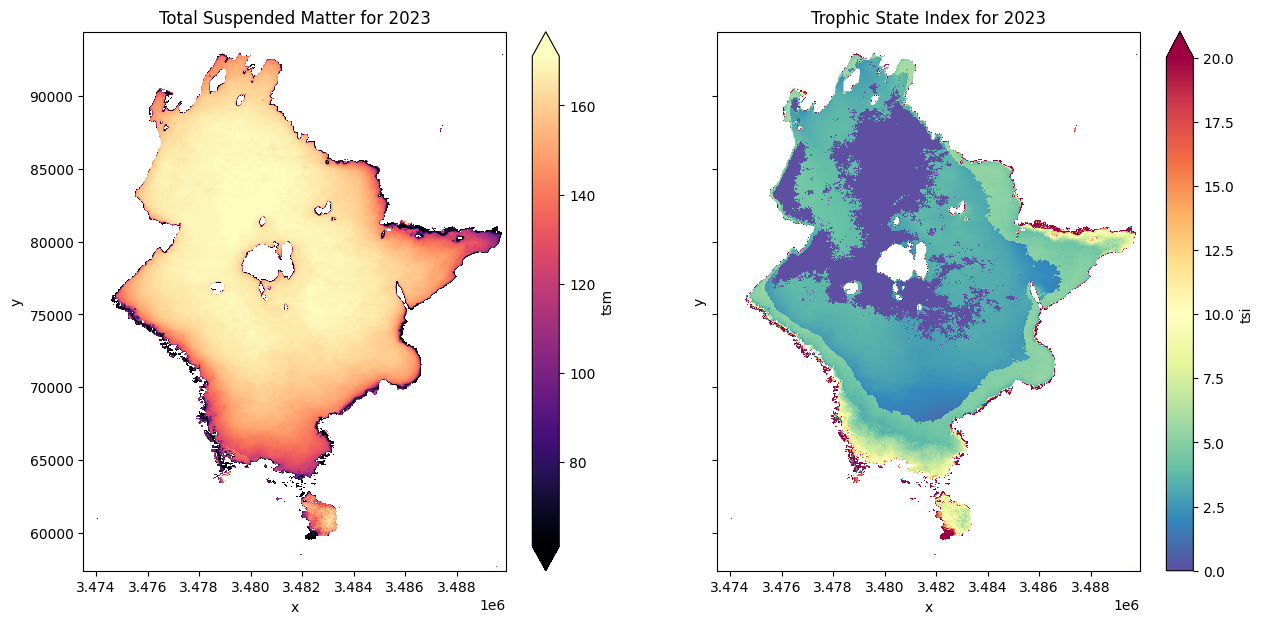

In [37]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(15, 7))

wq_ds["tsm_chla_tsi"]["tsm"].plot(cmap="magma",robust=True, ax=ax[0])
ax[0].set_title(f"Total Suspended Matter for {year}")

wq_ds["tsm_chla_tsi"]["tsi"].plot(cmap='Spectral_r', robust=True, ax=ax[1])
ax[1].set_title(f"Trophic State Index for {year}")

plt.show()

Write the annual water quality variables to COG files and save the STAC metadata.

In [38]:
measurement_paths: list[str] = []
for wq_var_group in list(wq_ds.keys()):
    ds = wq_ds[wq_var_group]
    if isinstance(ds, xr.DataArray):
        name = ds.name
        ds = ds.to_dataset(name=name)

    # Save each band as COG
    fs = get_filesystem(output_directory, anon=False)
    bands = list(ds.data_vars.keys())
    for band in bands:
        da = ds[band]
        if da.size == 0:
            continue
        # Set attributes
        if "scales" not in list(da.attrs.keys()):
            da.attrs = dict(
                nodata=np.nan,
                scales=1,
                offsets=0,
                product_name=product_name,
                product_version=product_version,
            )
        else:
            da.attrs.update(
                dict(
                    product_name=product_name,
                    product_version=product_version,
                )
            )

        # Write COG
        cog_bytes = write_cog(
            geo_im=da,
            fname=":mem:",
            overwrite=True,
            nodata=da.attrs["nodata"],
            tags=da.attrs,
        )

        output_cog_url = get_wq_cog_url(
            output_directory=output_directory,
            tile_id=tile_id,
            temporal_id=temporal_id,
            band_name=band,
            product_name=product_name,
            product_version=product_version,
        )
        with fs.open(output_cog_url, "wb") as f:
            f.write(cog_bytes)
        log.info(f"Band {band} saved to {output_cog_url}")
        measurement_paths.append(output_cog_url)

    if wq_var_group == "tsm_chla_tsi":
        # Save WQ parameters table
        output_csv_url = get_wq_csv_url(
            output_directory=output_directory,
            tile_id=tile_id,
            temporal_id=temporal_id,
            product_name=product_name,
            product_version=product_version,
        )
        with fs.open(output_csv_url, mode="w") as f:
            wq_vars_df.to_csv(f, index=False)
        log.info(f"WQ parameters table saved to {output_csv_url}")

# Generate STAC metadata
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    log.info("Creating metadata STAC file ...")
    stac_file_url = prepare_dataset(  # noqa F841
        measurement_paths=measurement_paths,
    )

log.info(f"Successfully processed task: {task_id_str}")

2026-01-09 11:47:39,341 __main__ [INFO]: Band water_mask saved to test/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_water_mask.tif
2026-01-09 11:47:40,047 __main__ [INFO]: Band tirs_st_ann_med saved to test/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_tirs_st_ann_med.tif
2026-01-09 11:47:40,736 __main__ [INFO]: Band tirs_st_ann_min saved to test/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_tirs_st_ann_min.tif
2026-01-09 11:47:41,436 __main__ [INFO]: Band tirs_st_ann_max saved to test/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_tirs_st_ann_max.tif
2026-01-09 11:47:41,666 __main__ [INFO]: Band msi_agm_fai saved to test/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_msi_agm_fai.tif
2026-01-09 11:47:41,893 __main__ [INFO]: Band oli_agm_fai saved to test/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_oli_agm_fai.tif
2026-01-09 11:47:42,120 __main__ [INFO]: Band agm_fai saved 